In [26]:
import sys, os

ROOT_DIR = r"C:\Users\vigne\OneDrive\Desktop\Motorcycle-Theft-Intelligence"

if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

print("ROOT SET:", ROOT_DIR)
print("SRC exists:", os.path.exists(os.path.join(ROOT_DIR, "src")))


ROOT SET: C:\Users\vigne\OneDrive\Desktop\Motorcycle-Theft-Intelligence
SRC exists: True


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    accuracy_score
)

sns.set(style="whitegrid")


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    accuracy_score
)

sns.set(style="whitegrid")


In [29]:
from src.utils import load_csv

df_feat = load_csv("../data/processed/features.csv")
df_feat.head()


,t_mid,speed_mean,speed_std,accel_mean,accel_std,vib_mean,engine_ratio,gps_jump_mean,label
0,2025-11-27 15:49:48.058601,0.206232,0.082677,0.227599,0.135005,0.013854,0.0,0.196476,0
1,2025-11-27 15:49:53.058601,0.212603,0.076122,0.189858,0.119902,0.016328,0.0,0.213699,0
2,2025-11-27 15:49:58.058601,0.174061,0.105248,0.181871,0.094752,0.019563,0.0,0.169342,0
3,2025-11-27 15:50:03.058601,0.155501,0.112252,0.146645,0.087103,0.015249,0.0,0.171309,0
4,2025-11-27 15:50:08.058601,0.149673,0.092410,0.158080,0.068832,0.014041,0.0,0.161341,0


In [30]:
print("Before cleaning:", df_feat.shape)
print("Labels:", df_feat['label'].value_counts())

# Drop timestamp column — NOT for ML (string)
df_feat = df_feat.drop(columns=["t_mid"], errors="ignore")

# Remove bad values
df_feat = df_feat.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print("After cleaning:", df_feat.shape)
df_feat.head()


Before cleaning: (877, 9)
Labels: label
0    862
1     15
Name: count, dtype: int64
After cleaning: (876, 8)


,speed_mean,speed_std,accel_mean,accel_std,vib_mean,engine_ratio,gps_jump_mean,label
0,0.206232,0.082677,0.227599,0.135005,0.013854,0.0,0.196476,0
1,0.212603,0.076122,0.189858,0.119902,0.016328,0.0,0.213699,0
2,0.174061,0.105248,0.181871,0.094752,0.019563,0.0,0.169342,0
3,0.155501,0.112252,0.146645,0.087103,0.015249,0.0,0.171309,0
4,0.149673,0.092410,0.158080,0.068832,0.014041,0.0,0.161341,0


In [31]:
from src.model_training import train_random_forest
import os

# Make sure models folder exists
os.makedirs("../models", exist_ok=True)

clf, X_test, y_test = train_random_forest(df_feat, save_model=True)


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       215
           1       1.00      1.00      1.00         4

    accuracy                           1.00       219
   macro avg       1.00      1.00      1.00       219
weighted avg       1.00      1.00      1.00       219



FileNotFoundError: [Errno 2] No such file or directory: 'models/random_forest.pkl'

In [34]:
# ensure models folder exists at project root as well (safety)
os.makedirs(os.path.join(ROOT_DIR, "models"), exist_ok=True)

# run training
from src.model_training import train_random_forest
clf, X_test, y_test = train_random_forest(df_feat, save_model=True)


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       215
           1       1.00      1.00      1.00         4

    accuracy                           1.00       219
   macro avg       1.00      1.00      1.00       219
weighted avg       1.00      1.00      1.00       219

Saved model -> c:\Users\vigne\OneDrive\Desktop\Motorcycle-Theft-Intelligence\models\random_forest.pkl
Saved scaler -> c:\Users\vigne\OneDrive\Desktop\Motorcycle-Theft-Intelligence\models\scaler.pkl


Accuracy: 1.0
AUROC: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       215
           1       1.00      1.00      1.00         4

    accuracy                           1.00       219
   macro avg       1.00      1.00      1.00       219
weighted avg       1.00      1.00      1.00       219



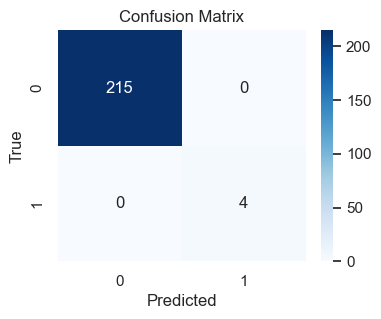

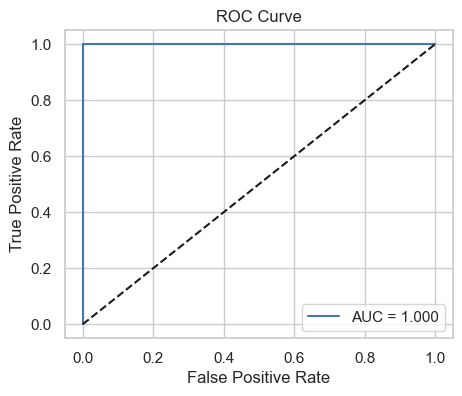

In [36]:
# Safe probability extraction
try:
    y_prob = clf.predict_proba(X_test)
except:
    # fallback if wrapper uses clf.model
    y_prob = clf.model.predict_proba(clf.scaler.transform(X_test))[:,1]

# Ensure 1-dimensional
if y_prob.ndim > 1:
    y_prob = y_prob[:, 1]

# Convert to binary prediction
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [37]:
import os
import pandas as pd

# Save classification report
report = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(report).to_csv("../models/classification_report.csv")

# Save predictions
pred_df = X_test.copy()
pred_df["y_true"] = y_test.values
pred_df["y_prob"] = y_prob
pred_df["y_pred"] = y_pred
pred_df.to_csv("../models/sample_predictions.csv", index=False)

print("Saved:")
print("- ../models/classification_report.csv")
print("- ../models/sample_predictions.csv")


Saved:
- ../models/classification_report.csv
- ../models/sample_predictions.csv
